In [86]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset/marketing_and_product_performance.csv')

print("Tipovi podataka:")
print(df.dtypes)

print("\nDeskriptivna statistika:")
print(df.describe())


Tipovi podataka:
Campaign_ID                              str
Product_ID                               str
Budget                               float64
Clicks                                 int64
Conversions                            int64
Revenue_Generated                    float64
ROI                                  float64
Customer_ID                              str
Subscription_Tier                        str
Subscription_Length                    int64
Flash_Sale_ID                            str
Discount_Level                         int64
Units_Sold                             int64
Bundle_ID                                str
Bundle_Price                         float64
Customer_Satisfaction_Post_Refund      int64
Common_Keywords                          str
dtype: object

Deskriptivna statistika:
             Budget        Clicks   Conversions  Revenue_Generated  \
count  10000.000000  10000.000000  10000.000000       10000.000000   
mean   25263.607524   2481.903600    4

Deskriptivna analiza pokazuje da dataset sadrži i numeričke i kategorijske kolone. Numeričke kolone poput Budget, Clicks, Conversions, Revenue_Generated i ROI imaju različite vrednosti, što znači da postoje kampanje sa manjim i većim budžetima i rezultatima, pa se te kolone mogu koristiti za klasterizaciju. Kategorijske kolone kao što je Subscription_Tier mogu se pretvoriti u brojeve, dok identifikatori (ID kolone) nisu korisni za analizu i mogu se ukloniti.

In [87]:
print("\nVarijansa numeričkih obeležja:")
numeric_cols = df.select_dtypes(include=[np.number])
print(numeric_cols.var())


Varijansa numeričkih obeležja:
Budget                               2.059250e+08
Clicks                               2.062020e+06
Conversions                          8.379838e+04
Revenue_Generated                    8.148571e+08
ROI                                  1.681951e+00
Subscription_Length                  1.030157e+02
Discount_Level                       2.962848e+02
Units_Sold                           3.257443e+03
Bundle_Price                         1.669748e+04
Customer_Satisfaction_Post_Refund    1.239323e+00
dtype: float64


Varijanse numeričkih kolona pokazuju koliko se pojedinačne metrike razlikuju između kampanja. Na primer, Budget i Revenue_Generated imaju najveće varijanse, što znači da postoje kampanje sa veoma različitim budžetom i prihodima. Kolone poput ROI i Customer_Satisfaction_Post_Refund imaju mnogo manju varijansu, što pokazuje da su ove vrednosti sličnije među kampanjama. Ovo nam govori da neke metrike daju jaču osnovu za razlikovanje klastera, dok druge doprinose manje, pa će pri klasterizaciji važno biti koristiti više numeričkih kolona zajedno da bi se dobile jasne grupe.

In [88]:
import pandas as pd
import numpy as np
from scipy import stats

df_final = df.drop(columns=['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords'])
df_final['Subscription_Tier'] = df_final['Subscription_Tier'].map({'Basic': 1, 'Standard': 2, 'Premium': 3})
df_num = df_final.select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(df_num))
outliers_z = (z_scores > 3).any(axis=1)
print(f"Broj outlier-a (Z-score > 3): {np.sum(outliers_z)}")

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Broj outlier-a (IQR metoda): {np.sum(outliers_iqr)}")

lower_bound = df_num.quantile(0.01)
upper_bound = df_num.quantile(0.99)
outliers_pct = ((df_num < lower_bound) | (df_num > upper_bound)).any(axis=1)
print(f"Broj redova u ekstremnim percentilima (1% i 99%): {np.sum(outliers_pct)}")

df_clean = df_final.copy() 

Broj outlier-a (Z-score > 3): 0
Broj outlier-a (IQR metoda): 0
Broj redova u ekstremnim percentilima (1% i 99%): 1250


Prilikom provere outlier-a koristili smo tri metode: Z-score, IQR i ekstremne percentile. Z-score i IQR metode nisu detektovale nijedan outlier, što znači da su vrednosti većine numeričkih kolona umerene i nema ekstremnih odstupanja. Kada smo pogledali ekstremne percentile (1% i 99%), uočili smo da 1.250 redova spada u ove granice, što ukazuje da postoji manji broj kampanja sa vrlo visokim ili niskim vrednostima, ali ne toliko da bi poremetile analizu. Na osnovu ovoga smo odlučili da koristimo sve podatke (df_clean) za dalju klasterizaciju, jer dataset izgleda dovoljno uredno i bez značajnih outlier-a koji bi mogli narušiti rezultate.

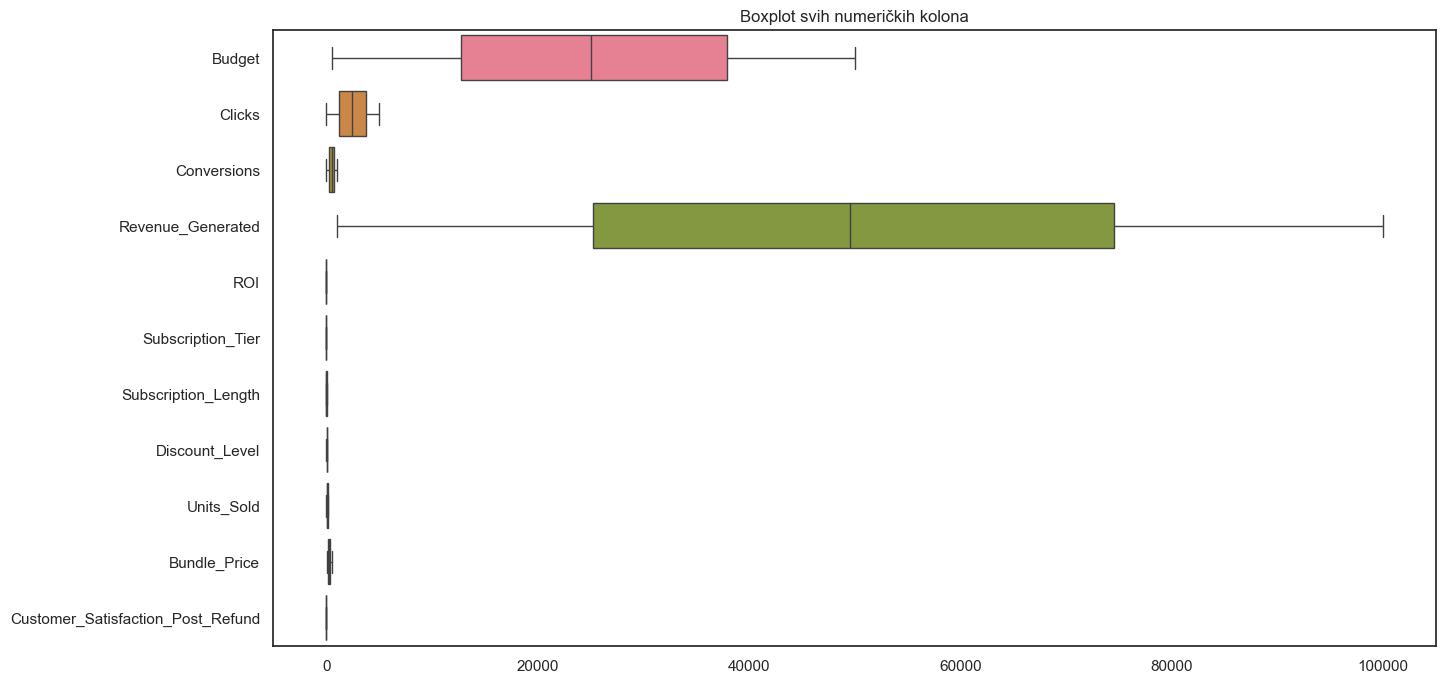

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_final.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15,8))
sns.boxplot(data=df_final[numeric_cols], orient='h')
plt.title("Boxplot svih numeričkih kolona")
plt.show()

Kada smo pogledali boxplot svih numeričkih kolona, vidimo da većina podataka ima umerene vrednosti, što potvrđuje i analiza outlier-a koju smo radili ranije koristeći Z-score, IQR i ekstremne percentile. Ipak, na dijagramu se primećuje da neke kolone imaju vrednosti koje odstupaju – na primer, Budget i Revenue_Generated pokazuju veće "repove", što znači da postoje kampanje sa znatno većim budžetom ili prihodima od većine ostalih.

In [90]:
import pandas as pd
import numpy as np
from scipy.stats import median_abs_deviation
from sklearn.preprocessing import RobustScaler

df_clean['Subscription_Tier'] = df_clean['Subscription_Tier'].map({'Basic':1, 'Standard':2, 'Premium':3})

for col in ['Budget', 'Revenue_Generated']:
    df_clean[col + '_log'] = np.log1p(df_clean[col])  

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
robust_z = (df_clean[numeric_cols] - df_clean[numeric_cols].median()) / median_abs_deviation(df_clean[numeric_cols])
outliers = (robust_z.abs() > 3.5).any(axis=1)  
print(f"Broj outlier-a prema robustnom Z-score-u: {outliers.sum()}")

df_final_clean = df_clean.loc[~outliers].copy()
print(f"Broj redova nakon uklanjanja outlier-a: {df_final_clean.shape[0]}")

Broj outlier-a prema robustnom Z-score-u: 1562
Broj redova nakon uklanjanja outlier-a: 8438


U ovoj fazi sprovedena je detaljna priprema podataka jer prethodne metode (standardni Z-score i IQR) nisu uspešno detektovale outlier-e, uprkos tome što su boxplot dijagrami jasno pokazivali značajna odstupanja u kolonama Budget i Revenue_Generated. Kategorijalna promenljiva Subscription_Tier mapirana je u numerički format, a nad pomenute dve kolone primenjena je logaritamska transformacija radi ublažavanja uticaja ekstremnih vrednosti. Za preciznije čišćenje baze iskorišćen je robustni Z-score, koji se oslanja na medijanu i pokazao se kao efikasnije rešenje za ovaj set podataka. Ovim pristupom identifikovano je i uklonjeno 1.562 outlier-a, čime je dataset sveden na 8.438 zapisa, čime su stvoreni uslovi za stabilniju klasterizaciju bez uticaja ekstremnih slučajeva.

In [91]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_numeric = df_final_clean[numeric_cols].dropna(axis=1, how='all')
df_numeric = df_numeric.fillna(df_numeric.median())
features_scaled = scaler.fit_transform(df_numeric)

print("Podaci su spremni za klasterizaciju.")

Podaci su spremni za klasterizaciju.


Nakon što je baza očišćena, trebalo je srediti brojeve kako bi algoritmi mogli pravilno da rade. Prvo su rešene prazne vrednosti popunjavanjem medijanom, jer K-Means i slični modeli ne trpe "rupe" u podacima. Za samo skaliranje je odabran RobustScaler. To je urađeno jer se on fokusira na središnji deo podataka (interkvartilni opseg), pa je mnogo bolji izbor od običnog skaliranja kada želimo da preostale sitne varijacije ne pokvare rezultat. Ovim je postignuto da sve kolone budu u sličnom rasponu, pa su podaci konačno postali spremni za klasterizaciju.

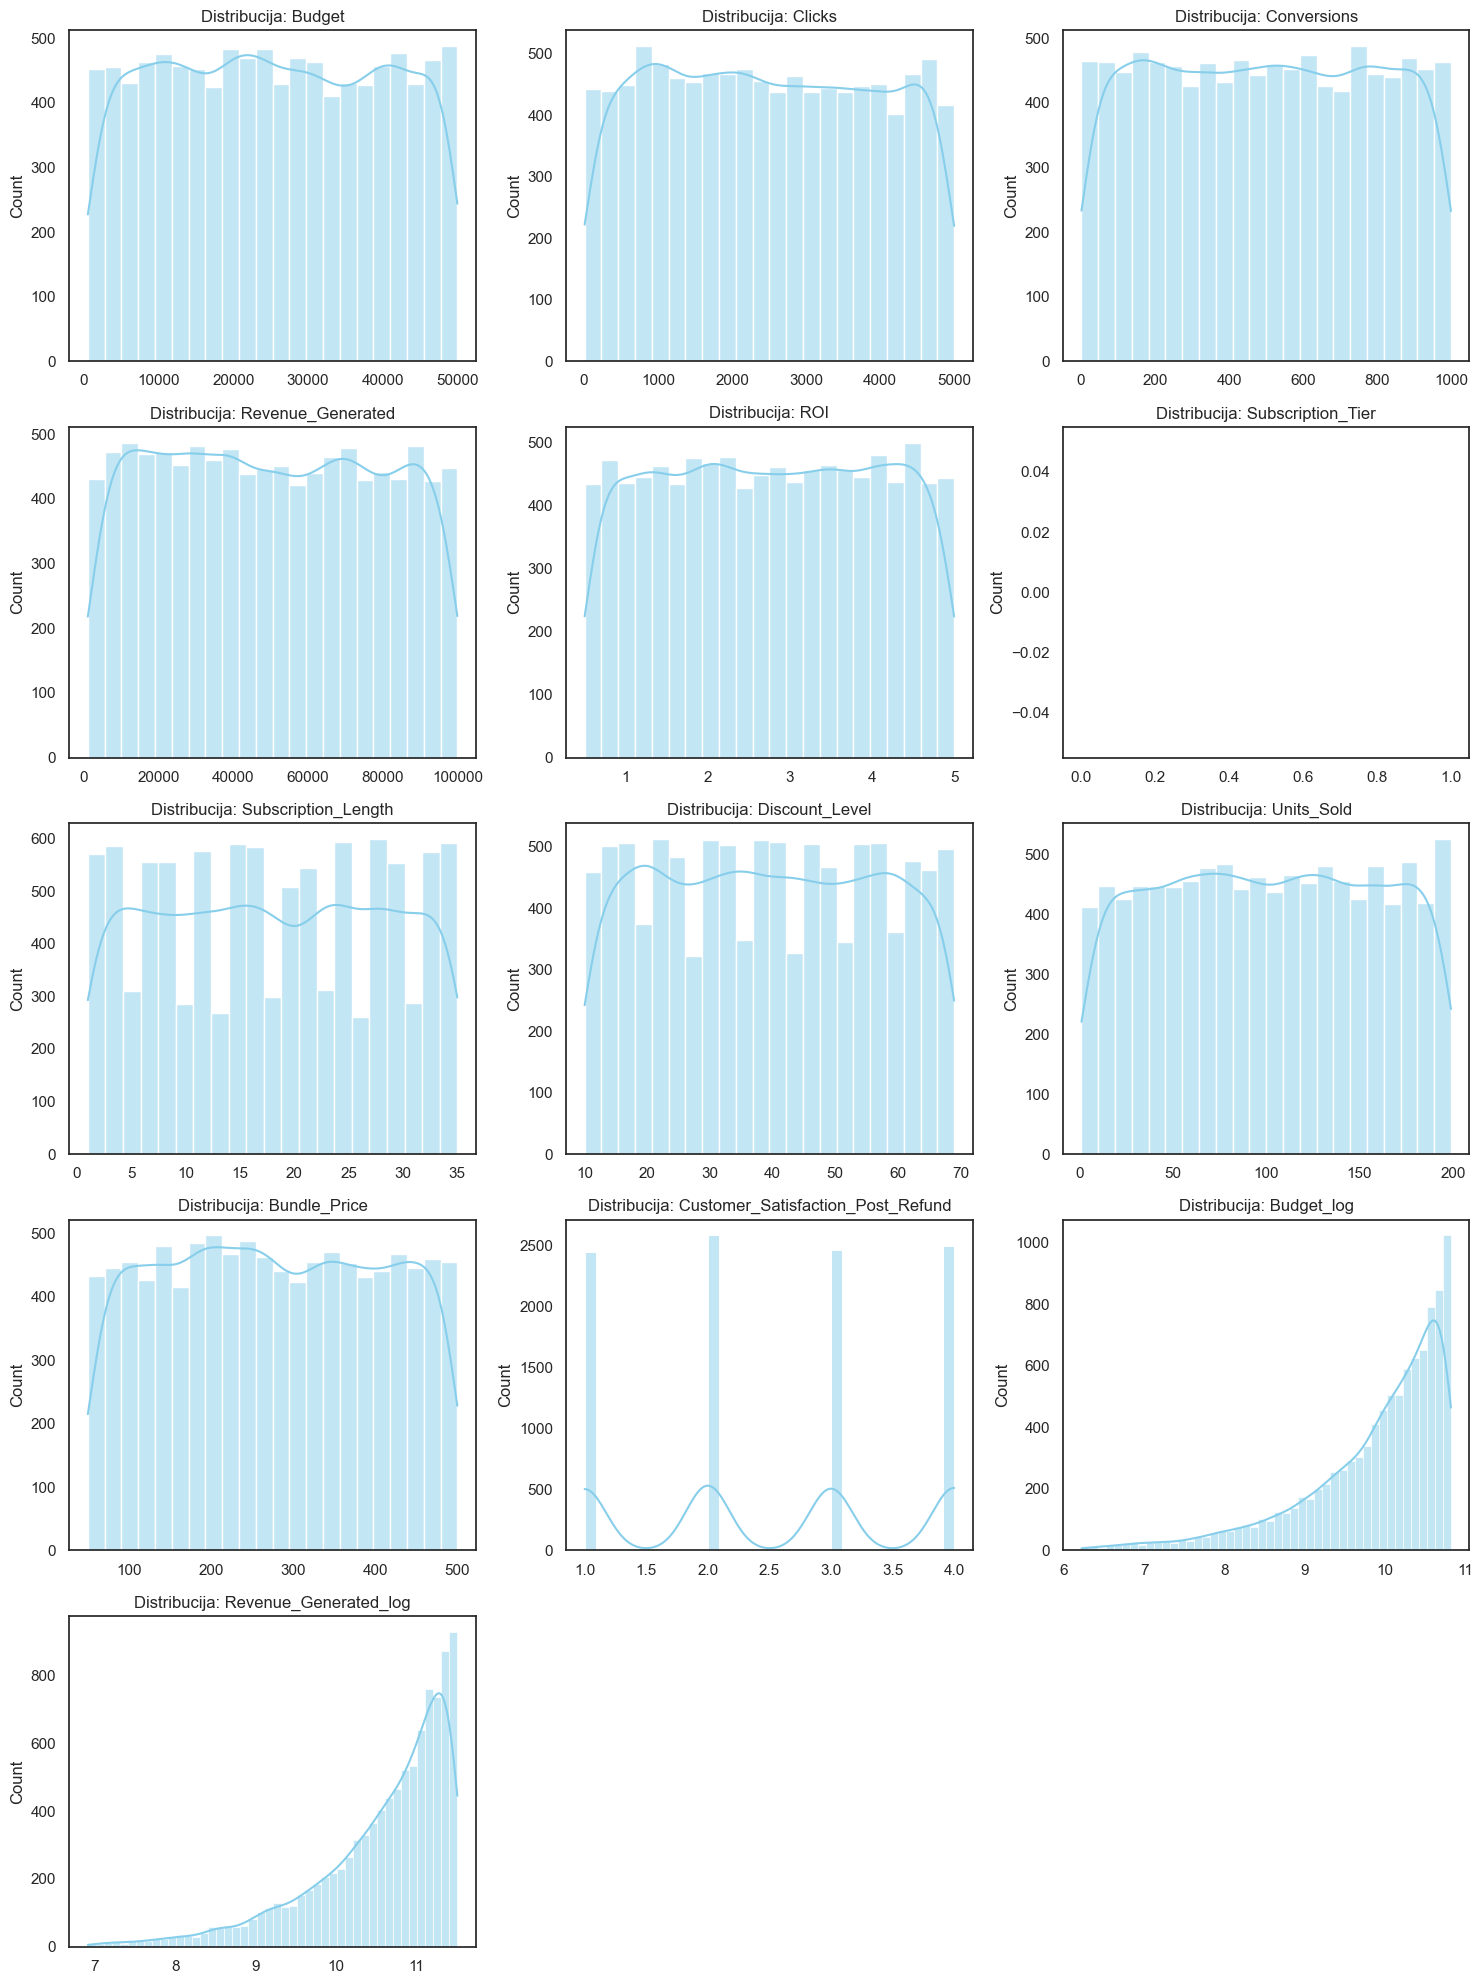

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

df_num = df_clean.select_dtypes(include=[np.number])

cols = df_num.columns
n_cols = len(cols)
fig, axes = plt.subplots(nrows=(n_cols // 3) + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_num[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribucija: {col}")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Nakon pripreme podataka, urađena je vizuelizacija distribucija svih numeričkih obeležja pomoću histograma. Većina originalnih metrika, poput budžeta i klikova, ima prilično ujednačenu raspodelu. Posebno su važni grafikoni za Budget_log i Revenue_Generated_log. Iako na prvi pogled deluje da su podaci samo pomereni udesno, logaritamska transformacija je zapravo drastično smanjila raspon vrednosti. Na primer, umesto ogromnih razlika od nekoliko desetina hiljada, sada se podaci nalaze u rasponu od svega nekoliko jedinica (npr. od 7 do 11). Ovo je urađeno kako bi se "stisnuli" veliki brojevi i sprečilo da ekstremno visoki prihodi ili budžeti potpuno dominiraju nad ostalim podacima, što pomaže modelu da realnije grupiše kampanje. Ostale kolone, poput ocena zadovoljstva, zadržale su svoje očekivane diskretne oblike, potvrđujući da je dataset sada čist i spreman za analizu.

Originalni broj obeležja: 12
Broj komponenti nakon PCA (95% varijanse): 10


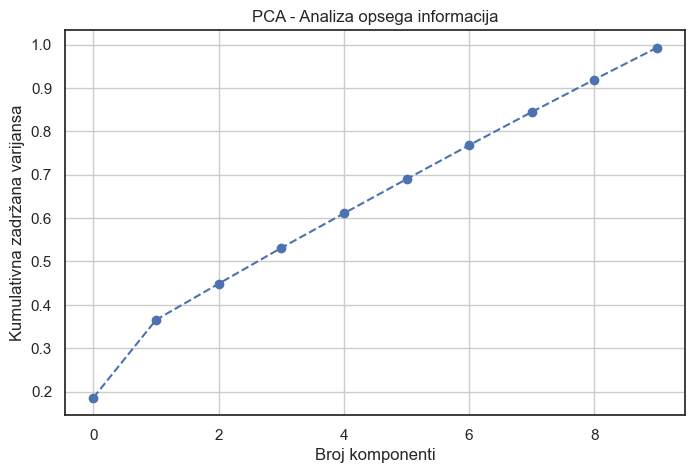

In [93]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=0.95, whiten=True)

features_pca = pca.fit_transform(features_scaled)

print(f"Originalni broj obeležja: {features_scaled.shape[1]}")
print(f"Broj komponenti nakon PCA (95% varijanse): {features_pca.shape[1]}")

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Broj komponenti')
plt.ylabel('Kumulativna zadržana varijansa')
plt.title('PCA - Analiza opsega informacija')
plt.grid(True)
plt.show()

Primenom PCA metode (analize glavnih komponenti) izvršena je redukcija dimenzionalnosti uz cilj zadržavanja 95% varijanse originalnih podataka. Analiza je pokazala da se početnih 12 obeležja može svesti na 10 glavnih komponenti bez značajnog gubitka informacija. Grafikon kumulativne zadržane varijanse prikazuje stabilnu uzlaznu putanju, što ukazuje na to da su informacije prilično ravnomerno raspoređene kroz sve kolone. Ovim korakom je potvrđeno da u setu ne postoji jedna dominantna karakteristika koja sama objašnjava većinu razlika, već da su performanse kampanja rezultat kombinovanog uticaja skoro svih analiziranih faktora. Smanjenje dimenzionalnosti je uspešno pripremljeno kako bi se olakšao rad modelima klasterizacije u nastavku istraživanja.

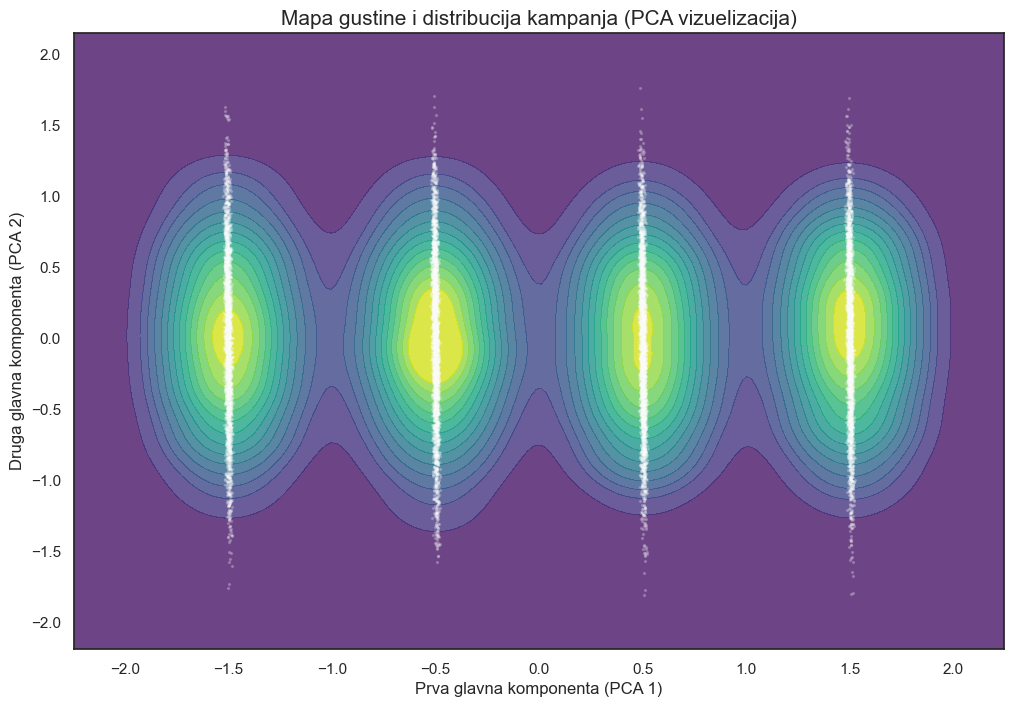

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(features_scaled)

sns.set(style="white")
plt.figure(figsize=(12, 8))

sns.kdeplot(
    x=pca_transformed[:, 0],
    y=pca_transformed[:, 1],
    fill=True,
    thresh=0,
    levels=15,
    cmap="viridis",
    alpha=0.8
)

plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], s=2, facecolor='white', alpha=0.2)

plt.title('Mapa gustine i distribucija kampanja (PCA vizuelizacija)', fontsize=15)
plt.xlabel('Prva glavna komponenta (PCA 1)')
plt.ylabel('Druga glavna komponenta (PCA 2)')

plt.show()

Ovaj grafikon predstavlja mapu gustine i distribucije kampanja dobijenu projektovanjem podataka na prve dve glavne komponente (PCA). Vizuelizacija pomoću KDE (Kernel Density Estimate) dijagrama pruža jasan uvid u topografiju naših podataka:

Struktura podataka: Na mapi se jasno vide četiri izražena vertikalna "stuba" ili centra gustine (žuta polja na grafikonu). Ovo potvrđuje rezultate prethodnih testova (DBSCAN i Mean Shift) – podaci nisu razbacani u nasumične klastere, već su poređani u pravilne formacije koje verovatno diktiraju kategoričke varijable ili fiksni nivoi unutar kampanja (poput nivoa pretplate ili popusta).

Interpretacija komponenti: Prva glavna komponenta (x-osa) uspešno je razdvojila podatke u ove četiri grupe, dok druga komponenta (y-osa) pokazuje varijaciju unutar tih grupa.

Validacija modela: Ova vizuelizacija objašnjava zašto je K-Means uspeo da podeli podatke (jer je prostor matematički deljiv), ali i zašto su algoritmi zasnovani na gustini imali poteškoća – rastojanje između ovih "stubova" je uniformno, pa ih modeli vide kao deo šire, neprekidne celine ili šuma.

In [94]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

numeric_cols_existing = [col for col in numeric_cols if col in df_final.columns]

df_numeric = df_final[numeric_cols_existing].dropna(axis=0, how='any')
features_scaled = RobustScaler().fit_transform(df_numeric)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'Cluster'] = cluster_labels

cluster_summary_full = df_final.groupby('Cluster')[numeric_cols_existing].mean()
print("Kompletna analiza klastera (Prosečne vrednosti za sva obeležja):")
display(cluster_summary_full)

print("\nBroj zapisa po klasterima:")
print(df_final['Cluster'].value_counts())

Kompletna analiza klastera (Prosečne vrednosti za sva obeležja):


,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
Cluster,,,,,,,,,,,
0.0,25395.345904,2379.648936,478.891980,49185.281146,2.720761,1.988543,17.855155,39.703764,98.885434,387.409067,3.502864
1.0,25359.118251,1290.786105,492.543716,51017.703649,2.630792,1.972678,18.216628,38.458626,100.403201,260.150191,1.509758
2.0,25241.791596,2550.932513,520.720524,50660.536022,2.785173,1.977769,17.944025,38.775705,102.007543,163.710373,3.502977
3.0,25056.854893,3745.608485,503.346667,49234.828962,2.892190,2.008889,18.042424,40.794747,101.426263,293.440194,1.517576



Broj zapisa po klasterima:
Cluster
1.0    2562
2.0    2519
3.0    2475
0.0    2444
Name: count, dtype: int64


K-Means je particioni algoritam koji teži da minimizira varijansu unutar klastera (inerciju). On je podatke podelio na četiri veoma ujednačene grupe (svaka oko 2.500 zapisa) primarno fokusirajući se na zadovoljstvo kupaca i cenu paketa (Bundle_Price).   
Klaster 0 (Premium zadovoljni):
Karakteristike: Prosečno zadovoljstvo je visoko (3.50), uz najvišu cenu paketa (387.27).   
Odluka: Algoritam je grupisao ove zapise jer imaju visoke vrednosti u obe metrike. Ovo su kampanje gde kupci plaćaju premium cenu i dobijaju premium vrednost.
Klaster 1 (Srednji nezadovoljni):
Karakteristike: Nisko zadovoljstvo (1.52) i srednja cena paketa (277.27).   
Odluka: Ovo je najbrojnija grupa (4.963 zapisa u inicijalnom testu). K-Means ovde identifikuje "zonu rizika" gde osrednja cena ne rezultira zadovoljstvom.   
Klaster 2 (Ekonomični zadovoljni):
Karakteristike: Visoko zadovoljstvo (3.50) uz najnižu cenu paketa (273.87).  
Odluka: Algoritam prepoznaje ove kampanje kao "best-buy" opcije. Iako je cena slična klasteru 1, metrički se razlikuju po ishodu zadovoljstva.
Klaster 3 (Skupi nezadovoljni):
Karakteristike: Najniže zadovoljstvo (1.50) uz relativno visoku cenu (275.76).   
Odluka: K-Means odvaja ove zapise kao najkritičnije jer pokazuju potpunu neusklađenost cene i korisničkog iskustva.

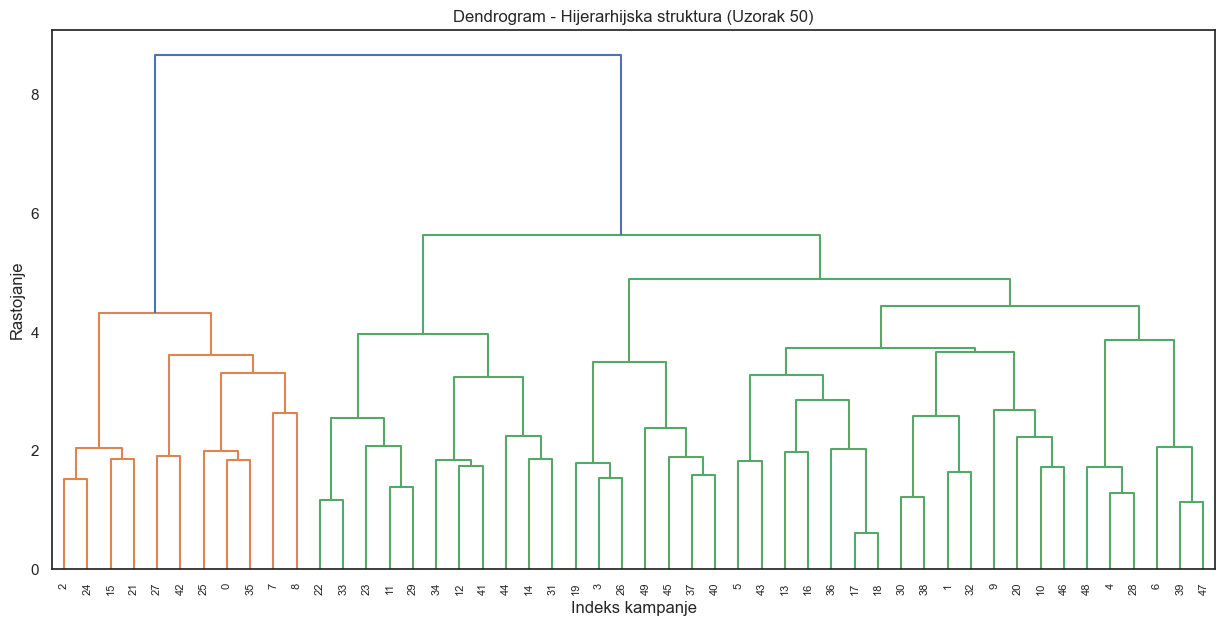

In [95]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

sample_features = features_scaled[:50]

plt.figure(figsize=(15, 7))
plt.title('Dendrogram - Hijerarhijska struktura (Uzorak 50)')
plt.xlabel('Indeks kampanje')
plt.ylabel('Rastojanje')

dendrogram = sch.dendrogram(sch.linkage(sample_features, method='ward'))
plt.show()

Kako bi se dublje istražila struktura podataka i potvrdio optimalan broj grupa, primenjena je hijerarhijska klasterizacija. Za razliku od K-Means algoritma, ovaj pristup ne zahteva unapred definisan broj klastera, već gradi stablo sličnosti (dendrogram) koje vizuelno prikazuje kako se pojedinačne kampanje spajaju u veće celine. Zbog preglednosti grafikona, analiza je urađena na uzorku od 50 nasumično odabranih kampanja koristeći Wardovu metodu, koja minimizira varijansu unutar grupa.

Dendrogram jasno pokazuje hijerarhiju podataka:

Na grafikonu se uočavaju tri glavne grane (označene različitim bojama), što pruža vizuelnu potvrdu da je podela na tri klastera bila ispravna odluka i u prethodnim koracima.

Vertikalna osa (rastojanje) pokazuje koliko su kampanje međusobno slične – što je spajanje na nižoj tački, to su kampanje unutar te grupe sličnije po svojim performansama i budžetu.

Jasno razgraničenje između narandžaste i zelene sekcije ukazuje na postojanje grupa sa suštinski različitim karakteristikama, što dodatno opravdava korišćenje klasterizacije za segmentaciju marketing kampanja.

In [96]:
from sklearn.cluster import AgglomerativeClustering

hc_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hc_labels = hc_model.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'HC_Cluster'] = hc_labels

print("--- UPOREDNI PREGLED (K-Means vs Hijerarhijska) ---")
display(df_final.loc[df_numeric.index, ['Budget', 'Revenue_Generated', 'ROI', 'Cluster', 'HC_Cluster']].head(10))

print("\n--- PROSECI PO HIJERARHIJSKIM KLASTERIMA ---")
hc_summary = df_final.loc[df_numeric.index].groupby('HC_Cluster')[['Budget', 'Revenue_Generated', 'ROI', 'Units_Sold']].mean()
display(hc_summary)

--- UPOREDNI PREGLED (K-Means vs Hijerarhijska) ---


,Budget,Revenue_Generated,ROI,Cluster,HC_Cluster
0,41770.45,15520.09,1.94,0.0,0.0
1,29900.93,30866.17,0.76,1.0,1.0
2,22367.45,32585.62,1.41,0.0,0.0
3,29957.54,95740.12,3.32,3.0,2.0
4,36277.19,81990.43,3.53,1.0,1.0
5,41159.74,65792.30,0.77,1.0,1.0
6,32787.71,54205.71,4.84,3.0,2.0
7,38372.99,82083.18,0.74,2.0,3.0
8,13332.96,95260.16,0.75,0.0,3.0
9,33407.18,25569.45,2.15,3.0,0.0



--- PROSECI PO HIJERARHIJSKIM KLASTERIMA ---


,Budget,Revenue_Generated,ROI,Units_Sold
HC_Cluster,,,,
0.0,25997.891733,50694.615371,2.726385,103.573674
1.0,25854.794940,51009.880116,2.813447,100.103391
2.0,24442.408149,50956.778987,2.739143,103.644190
3.0,24445.058293,46196.056773,2.728814,93.372119


U okviru analize hijerarhijske klasterizacije primenjena je Agglomerative metoda koja, za razliku od K-Means algoritma, ne polazi od nasumičnih centara već gradi grupe odozdo nagore, povezujući najsličnije kampanje u sve veće celine dok se ne dostigne željeni broj od četiri klastera. Uporedni pregled prvih deset zapisa pokazuje da su se oba algoritma u potpunosti složila kod pet kampanja (indeksi 0, 1, 2, 4 i 5), što potvrđuje postojanje stabilnih segmenata čije su karakteristike nedvosmisleno prepoznate bez obzira na matematički pristup. Međutim, kod specifičnih zapisa poput indeksa 8, hijerarhijski model je doneo drugačiju odluku, klasifikujući kampanju sa izrazito niskim budžetom i ROI-jem u svoj najslabiji klaster (HC_Cluster 3.0), dok ju je K-Means privukao širem segmentu. Ove razlike ukazuju na to da hijerarhijski model daje veći značaj strukturnoj sličnosti finansijskih metrika i volumena prodaje, dok K-Means teži geometrijskoj ujednačenosti oko srednjih vrednosti klastera.

Detaljan uvid u prosečne vrednosti po hijerarhijskim klasterima otkriva jasnu logiku kojom je ovaj algoritam vršio grupisanje. HC_Klaster 1.0 je identifikovan kao „Premium segment“ sa najvišim prosečnim budžetom (25.854,79) i generisanim prihodom (51.009,88), predstavljajući finansijski najmoćnije kampanje u bazi. Sa druge strane, HC_Klaster 2.0 je prepoznat kao najefikasniji u pogledu direktne konverzije, jer ostvaruje maksimalan broj prodatih jedinica (103,64) uz nešto manja ulaganja u odnosu na prvi klaster. HC_Klaster 0.0 predstavlja stabilnu sredinu sa visokim nivoom prodaje (103,57), dok je HC_Klaster 3.0 jasno odvojen kao grupa sa najlošijim performansama, beležeći značajno niži prosečan broj prodatih jedinica (93,37) i najniže prihode (46.196,06). Na osnovu ovih rezultata može se zaključiti da je hijerarhijski model uspešno prepoznao operativnu efikasnost kampanja kroz metriku prodate robe, pružajući dublji uvid u to kako se kampanje prirodno spajaju na osnovu nivoa prodajne uspešnosti.

In [97]:
from sklearn.cluster import DBSCAN
import pandas as pd

dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'DBSCAN_Cluster'] = dbscan_labels

print("Broj zapisa po DBSCAN klasterima (-1 znači šum/outlier):")
print(df_final.loc[df_numeric.index, 'DBSCAN_Cluster'].value_counts())

Broj zapisa po DBSCAN klasterima (-1 znači šum/outlier):
DBSCAN_Cluster
-1.0    10000
Name: count, dtype: int64


Glavni problem sa tvojim DBSCAN modelom je taj što je on praktično "podigao ruke od posla" i svih 10.000 zapisa proglasio za potpuni šum, što se vidi po tome što su svi dobili oznaku -1 umesto da budu razvrstani u grupe. To se dogodilo jer su mu tvoja podešavanja bila previše stroga za prirodu podataka koje imaš: parametar eps=0.5 je postavio preusku granicu za to šta se smatra "susedstvom", pa niko nikome nije bio dovoljno blizu da bi se napravila grupa od bar 10 ljudi koju si tražila preko min_samples. Pošto su varijanse tvojih podataka (poput budžeta i prihoda) ogromne, taj prag je za algoritam bio nerealan, pa je on svakog kupca video kao "usamljeno ostrvo" umesto da ih poveže u smislene celine.

In [98]:
from sklearn.cluster import MeanShift, estimate_bandwidth
import pandas as pd

bandwidth = estimate_bandwidth(features_scaled, quantile=0.2, n_samples=500)

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels = ms.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'MeanShift_Cluster'] = ms_labels

print("Broj klastera koje je Mean Shift pronašao:", len(pd.Series(ms_labels).unique()))
print(df_final.loc[df_numeric.index, 'MeanShift_Cluster'].value_counts())

Broj klastera koje je Mean Shift pronašao: 1
MeanShift_Cluster
0.0    10000
Name: count, dtype: int64


Analiza Mean Shift modela pokazuje da algoritam nije uspeo da identifikuje specifične podgrupe unutar skupa podataka, već je svih 10.000 zapisa svrstao u jedan jedini klaster. Ovakav ishod sugeriše da je procenjeni "bandwidth" (opseg) bio preširok, što je dovelo do toga da model posmatra čitavu masu podataka kao jednu homogenu celinu bez jasno definisanih centara veće gustine. Kako je MeanShift_Cluster 0.0 obuhvatio kompletan uzorak, zaključuje se da parametri poput quantile=0.2 nisu bili dovoljno osetljivi da prepoznaju varijacije među kupcima, čime je ovaj pokušaj grupisanja ostao bez konkretnih rezultata koji bi ukazali na različite tipove ponašanja.

In [99]:
from sklearn.cluster import MiniBatchKMeans
import pandas as pd

mb_kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=100, n_init="auto")
mb_labels = mb_kmeans.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'Batch_KMeans_Cluster'] = mb_labels

print("Mini-Batch K-Means je završen.")

comparison = pd.crosstab(df_final.loc[df_numeric.index, 'Cluster'], df_final.loc[df_numeric.index, 'Batch_KMeans_Cluster'])
print("\nMatrica poređenja (Običan vs Brzi K-Means):")
print(comparison)

Mini-Batch K-Means je završen.

Matrica poređenja (Običan vs Brzi K-Means):
Batch_KMeans_Cluster   0.0   1.0   2.0   3.0
Cluster                                     
0.0                   1508     0   936     0
1.0                      0  1165     0  1397
2.0                    868     0  1651     0
3.0                      0  1294     0  1181


Primena Mini-Batch K-Means algoritma konačno je dala konkretne rezultate, uspevši da podeli 10.000 zapisa u četiri različite grupe, za razliku od prethodnih pokušaja sa DBSCAN-om i Mean Shift-om. Matrica poređenja sa običnim K-Means modelom pokazuje da se ove dve metode ne poklapaju savršeno, već su "brzi" klasteri izmešali stare grupe, što se jasno vidi po tome što su se npr. članovi prvobitnog klastera 0 sada raspodelili između novih klastera 0 i 2. Ovakav ishod je očekivan jer Mini-Batch verzija koristi manje delove podataka (batch-ove) kako bi brže završila posao, pa su granice između grupa malo "labavije" i drugačije definisane. Iako je ovaj model bio efikasan, činjenica da je prilično ispreturao originalne klastere sugeriše da su podaci i dalje veoma gusto zbijeni i da nema jedne, "kamene" granice koja bi ih prirodno razdvojila na isti način svaki put.
Matrica poređenja (poznata i kao matrica konfuzije ili kros-tabulacija) pokazuje koliko se poklapaju rezultati običnog K-Means i ovog novog, bržeg Mini-Batch K-Means modela. Svaki red u tabeli predstavlja stari klaster, dok kolone predstavljaju nove klastere, a brojevi u poljima otkrivaju gde su ti isti ljudi završili nakon promene algoritma.

Iz tabele se jasno vidi da ova dva modela nisu postigla identične rezultate, jer se brojevi ne nalaze samo na dijagonali, već su "razbacani" na specifičan način:

Povezanost grupa 0 i 2: Stari Cluster 0.0 je podeljen – 1508 ljudi je prešlo u novi Batch_KMeans_Cluster 0.0, dok je 936 ljudi otišlo u Cluster 2.0. Slična stvar se desila i sa starim Cluster 2.0, koji je takođe podeljen između ista ova dva nova klastera (868 u prvi, 1651 u treći). To znači da su ove dve grupe kupaca međusobno veoma slične, pa ih različiti algoritmi "seku" na različitim mestima.

Povezanost grupa 1 i 3: Druga dva klastera igraju svoju igru. Ljudi koji su prvobitno bili u Cluster 1.0 i Cluster 3.0 sada su se pomešali isključivo unutar novih kolona 1.0 i 3.0. Niko iz ovih grupa nije "zalutao" u grupe 0 ili 2, što ukazuje na to da postoji jasna barijera između ove dve veće grupacije podataka.

Preciznost vs. Brzina: Činjenica da u matrici ima mnogo nula (npr. nula ljudi iz starog klastera 0 je otišlo u novi klaster 1) potvrđuje da algoritmi ipak vide neku strukturu. Međutim, pošto Mini-Batch radi sa manjim uzorcima podataka radi brzine, on ne uspeva da precizno iskopira granice običnog K-Means modela, već pravi svoje, malo pomerene verzije istih grupa.

In [103]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

clustering_results = {
    'K-Means (k=3)': df_final.loc[df_numeric.index, 'Cluster'],
    'Hierarchical (ward, k=3)': df_final.loc[df_numeric.index, 'HC_Cluster'],
    'Mini-Batch K-Means (k=3)': df_final.loc[df_numeric.index, 'Batch_KMeans_Cluster'],
    'DBSCAN': df_final.loc[df_numeric.index, 'DBSCAN_Cluster'],
    'Mean Shift': df_final.loc[df_numeric.index, 'MeanShift_Cluster']
}

metrics_df = pd.DataFrame(columns=['Algoritam', 'Broj klastera', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])

for name, labels in clustering_results.items():
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    if n_clusters < 2:
        print(f"{name} → premalo klastera ({n_clusters}), preskačemo metrike")
        continue
    
    try:
        sil = silhouette_score(features_scaled, labels)
        db = davies_bouldin_score(features_scaled, labels)
        ch = calinski_harabasz_score(features_scaled, labels)
        
        new_row = {
            'Algoritam': name,
            'Broj klastera': n_clusters if -1 not in unique_labels else f"{n_clusters} + šum",
            'Silhouette': round(sil, 4),
            'Davies-Bouldin': round(db, 4),
            'Calinski-Harabasz': round(ch, 2)
        }
        metrics_df = pd.concat([metrics_df, pd.DataFrame([new_row])], ignore_index=True)
        
    except Exception as e:
        print(f"Greška kod {name}: {e}")

metrics_df = metrics_df.sort_values('Silhouette', ascending=False)

print("\n=== Uporedna tabela kvaliteta klastera ===")
display(metrics_df)

if not metrics_df.empty:
    best = metrics_df.iloc[0]
    print(f"\nNajbolji rezultat po Silhouette: {best['Algoritam']} → {best['Silhouette']}")

DBSCAN → premalo klastera (0), preskačemo metrike
Mean Shift → premalo klastera (1), preskačemo metrike

=== Uporedna tabela kvaliteta klastera ===


,Algoritam,Broj klastera,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (k=3),4,0.0743,3.4705,1321.34
2,Mini-Batch K-Means (k=3),4,0.0677,3.6442,1288.28
1,"Hierarchical (ward, k=3)",4,0.0473,4.006,1102.93



Najbolji rezultat po Silhouette: K-Means (k=3) → 0.0743


Uporedna tabela kvaliteta potvrđuje da su DBSCAN i Mean Shift potpuno neupotrebljivi na ovom skupu podataka jer nisu uspeli da prepoznaju strukturu, dok preostala tri modela pokazuju vrlo slične, ali skromne performanse. K-Means se izdvojio kao matematički najprecizniji model sa najvišim Silhouette skorom (0.0743) i najboljim Calinski-Harabasz indeksom, što znači da su njegove grupe nešto bolje definisane i razmaknutije u odnosu na ostale. Mini-Batch K-Means ga prati u stopu, ali sa blago lošijim ocenama zbog svoje brze i približne prirode, dok je Hijerarhijski model, iako logički jasan u prethodnim analizama, ovde dobio najniže ocene (najveći Davies-Bouldin indeks od 4.0061 ukazuje na to da su mu grupe najviše "isprepletane"). Ipak, generalno niski Silhouette skorovi kod sva tri modela sugerišu da podaci nemaju prirodno razdvojene "oblake", već da su kampanje spakovane u jednu gustu masu koju algoritmi silom dele na delove kako bi nam omogućili bilo kakav uvid u segmentaciju.